# IMPORTING LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


# LOADING DATASET

In [5]:
from google.colab import files
uploaded = files.upload()


Saving train-00000-of-00001-e1e9f7eca1c74261.parquet to train-00000-of-00001-e1e9f7eca1c74261.parquet


In [6]:
from google.colab import files
uploaded = files.upload()


Saving valid-00000-of-00001-902d7b6987b2a074.parquet to valid-00000-of-00001-902d7b6987b2a074.parquet


In [7]:
train_df = pd.read_parquet("train-00000-of-00001-e1e9f7eca1c74261.parquet")
valid_df = pd.read_parquet("valid-00000-of-00001-902d7b6987b2a074.parquet")

In [8]:
import os
os.listdir()


['.config',
 'valid-00000-of-00001-902d7b6987b2a074.parquet',
 'train-00000-of-00001-e1e9f7eca1c74261.parquet',
 'sample_data']

In [10]:
# load parquet files into dataframe
import pandas as pd

train_df = pd.read_parquet("train-00000-of-00001-e1e9f7eca1c74261.parquet")
valid_df = pd.read_parquet("valid-00000-of-00001-902d7b6987b2a074.parquet")


# DATA PREPROCESSING

In [14]:
train_df.head()



,unit_number,time_cycles,setting_1,setting_2,setting_3,s_1,s_2,s_3,s_4,s_5,...,s_13,s_14,s_15,s_16,s_17,s_18,s_19,s_20,s_21,RUL
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190,191
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236,190
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442,189
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739,188
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044,187


In [12]:
print(train_df.shape)
print(train_df.columns)

(20631, 27)
Index(['unit_number', 'time_cycles', 'setting_1', 'setting_2', 'setting_3',
       's_1', 's_2', 's_3', 's_4', 's_5', 's_6', 's_7', 's_8', 's_9', 's_10',
       's_11', 's_12', 's_13', 's_14', 's_15', 's_16', 's_17', 's_18', 's_19',
       's_20', 's_21', 'RUL'],
      dtype='object')


In [15]:
train_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20631 entries, 0 to 20630
Data columns (total 27 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   unit_number  20631 non-null  int64  
 1   time_cycles  20631 non-null  int64  
 2   setting_1    20631 non-null  float64
 3   setting_2    20631 non-null  float64
 4   setting_3    20631 non-null  float64
 5   s_1          20631 non-null  float64
 6   s_2          20631 non-null  float64
 7   s_3          20631 non-null  float64
 8   s_4          20631 non-null  float64
 9   s_5          20631 non-null  float64
 10  s_6          20631 non-null  float64
 11  s_7          20631 non-null  float64
 12  s_8          20631 non-null  float64
 13  s_9          20631 non-null  float64
 14  s_10         20631 non-null  float64
 15  s_11         20631 non-null  float64
 16  s_12         20631 non-null  float64
 17  s_13         20631 non-null  float64
 18  s_14         20631 non-null  float64
 19  s_15

In [16]:
THRESHOLD = 30  # cycles before failure

train_df["failure"] = train_df["RUL"].apply(
    lambda x: 1 if x <= THRESHOLD else 0
)


# DEFINING X AND Y

In [17]:
features = (
    [col for col in train_df.columns if col.startswith("s_")] +
    ["setting_1", "setting_2", "setting_3"]
)

X = train_df[features]
y = train_df["failure"]


# FEATURE SCALING

In [18]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


# TRAIN AND TEST SPLIT

In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# MODEL BUILDING

In [20]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


RandomForestClassifier(max_depth=15, n_estimators=200, n_jobs=-1,
                       random_state=42)

# MODEL EVALUATION

In [21]:
from sklearn.metrics import classification_report

y_pred = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.98      0.98      0.98      3507
           1       0.90      0.87      0.88       620

    accuracy                           0.96      4127
   macro avg       0.94      0.92      0.93      4127
weighted avg       0.96      0.96      0.96      4127



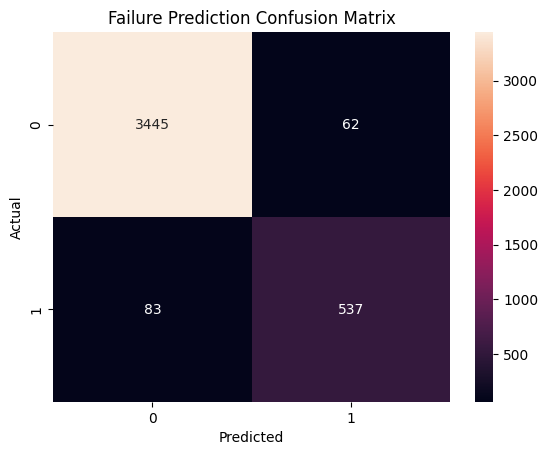

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(confusion_matrix(y_test, y_pred),
            annot=True, fmt="d")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Failure Prediction Confusion Matrix")
plt.show()


####
- ✅ 3445 times: Model correctly said “No failure” and it was true.
- ✅ 537 times: Model correctly said “Failure” and it was true.
- ❌ 62 times: Model wrongly said “Failure” but there was no failure.
- ❌ 83 times: Model wrongly said “No failure” but there was a failure.


In [23]:
import pandas as pd

importance = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

importance.head(10)


,feature,importance
10,s_11,0.167178
3,s_4,0.131868
11,s_12,0.104759
6,s_7,0.083326
14,s_15,0.082161
19,s_20,0.064946
20,s_21,0.064069
13,s_14,0.055658
8,s_9,0.055553
1,s_2,0.040382


In [24]:
import joblib

joblib.dump(rf, "predictive_maintenance_model.pkl")
joblib.dump(scaler, "scaler.pkl")


['scaler.pkl']